In [1]:
import pandas as pd

train_mwb = pd.read_csv("/content/mwb-train.csv")
test_mwb = pd.read_csv("/content/mwb-test.csv")

print("TRAIN:", train_mwb.shape)
print("TEST:", test_mwb.shape)

TRAIN: (1157, 30)
TEST: (321, 30)


In [2]:
print("Addiction Level - TRAIN")
print(train_mwb["Addiction_Level"].value_counts())

print("\nAddiction Level - TEST")
print(test_mwb["Addiction_Level"].value_counts())

Addiction Level - TRAIN
Addiction_Level
MODERATE    330
LOW         329
HIGH        288
SEVERE      210
Name: count, dtype: int64

Addiction Level - TEST
Addiction_Level
MODERATE    116
LOW          85
HIGH         66
SEVERE       54
Name: count, dtype: int64


In [3]:
# Target
y_train_add = train_mwb["Addiction_Level"]
y_test_add = test_mwb["Addiction_Level"]

# columnas a dropear
columnas_eliminar_add = [
    "User_ID",
    "Addiction_Level",
    "Mental_Wellbeing_Score"
]

X_train_add = train_mwb.drop(columns=columnas_eliminar_add)
X_test_add = test_mwb.drop(columns=columnas_eliminar_add)

print("X_train:", X_train_add.shape)
print("X_test:", X_test_add.shape)

print("\nVariables utilizadas:")
print(X_train_add.columns.tolist())

X_train: (1157, 27)
X_test: (321, 27)

Variables utilizadas:
['Age', 'Gender', 'Occupation', 'Relationship_Status', 'Primary_Platform', 'Daily_Usage_Hours', 'Platforms_Used_Count', 'Posts_Per_Week', 'Late_Night_Usage', 'First_Check_Morning', 'Notifications_Per_Day', 'FOMO_Score', 'Social_Comparison_Score', 'Validation_Seeking_Score', 'Scroll_Without_Purpose', 'Tried_To_Cut_Back', 'Failed_To_Cut_Back', 'Anxiety_Score', 'Depression_Score', 'Loneliness_Score', 'Self_Esteem_Score', 'Sleep_Quality_Score', 'Sleep_Hours', 'Productivity_Loss_Score', 'Offline_Relationship_Quality', 'Physical_Activity_Hrs_Week', 'Screen_Free_Time_Hrs']


In [4]:
categorical_features_add = X_train_add.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Variables categóricas:")
print(categorical_features_add)

Variables categóricas:
['Gender', 'Occupation', 'Relationship_Status', 'Primary_Platform', 'First_Check_Morning']


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor_add = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_add
        )
    ],
    remainder="passthrough"
)

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import pandas as pd

resultados_cv_add = []

for profundidad in [2, 3, 4, 5, 6, 7, 8, 10]:

    tree_add = DecisionTreeClassifier(
        max_depth=profundidad,
        random_state=46,
        class_weight="balanced"
    )

    model_cv_add = Pipeline(
        steps=[
            ("preprocessor", preprocessor_add),
            ("classifier", tree_add)
        ]
    )

    scores = cross_val_score(
        model_cv_add,
        X_train_add,
        y_train_add,
        cv=5,
        scoring="f1_macro"
    )

    resultados_cv_add.append({
        "max_depth": profundidad,
        "f1_macro_promedio": scores.mean(),
        "desviacion": scores.std()
    })

resultados_cv_add_df = pd.DataFrame(resultados_cv_add)

resultados_cv_add_df

,max_depth,f1_macro_promedio,desviacion
0,2,0.336134,0.049817
1,3,0.360374,0.029733
2,4,0.371753,0.028092
3,5,0.385882,0.023606
4,6,0.388295,0.021717
5,7,0.394024,0.034456
6,8,0.400207,0.019040
7,10,0.372067,0.031591


In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

final_tree_add = DecisionTreeClassifier(
    max_depth=8,
    random_state=46,
    class_weight="balanced"
)

final_model_add = Pipeline(
    steps=[
        ("preprocessor", preprocessor_add),
        ("classifier", final_tree_add)
    ]
)

# Entrenar con todo TRAIN
final_model_add.fit(X_train_add, y_train_add)

# Predecir sobre TEST
y_pred_add = final_model_add.predict(X_test_add)

In [9]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

accuracy_add = accuracy_score(
    y_test_add,
    y_pred_add
)

f1_macro_add = f1_score(
    y_test_add,
    y_pred_add,
    average="macro"
)

print(f"Accuracy Addiction: {accuracy_add:.4f}")
print(f"Accuracy Addiction (%): {accuracy_add * 100:.2f}%")
print(f"F1 Macro Addiction: {f1_macro_add:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_add,
        y_pred_add,
        zero_division=0
    )
)

Accuracy Addiction: 0.3738
Accuracy Addiction (%): 37.38%
F1 Macro Addiction: 0.3780

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.26      0.36      0.30        66
         LOW       0.49      0.47      0.48        85
    MODERATE       0.38      0.29      0.33       116
      SEVERE       0.39      0.41      0.40        54

    accuracy                           0.37       321
   macro avg       0.38      0.38      0.38       321
weighted avg       0.39      0.37      0.38       321



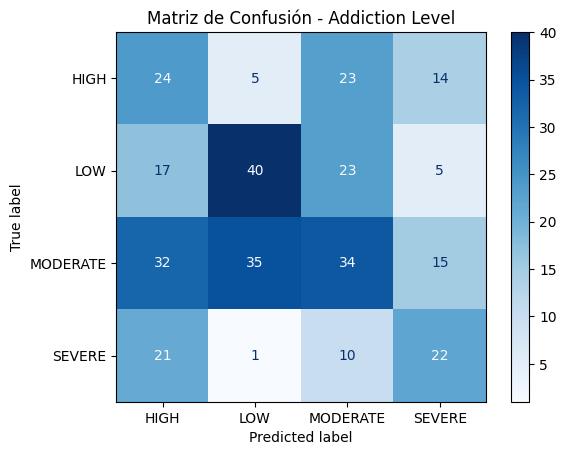

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_add,
    y_pred_add,
    cmap="Blues"
)

plt.title("Matriz de Confusión - Addiction Level")
plt.show()

El modelo de Addiction Level obtuvo un accuracy del 37.07% y un F1 Macro de 0.38. La matriz de confusión muestra una elevada superposición entre las categorías, especialmente en Moderate, lo que indica que las variables disponibles no separan de forma clara los distintos niveles de adicción mediante este árbol de decisión

In [11]:
feature_names_add = final_model_add.named_steps[
    "preprocessor"
].get_feature_names_out()

importances_add = final_model_add.named_steps[
    "classifier"
].feature_importances_

feature_importance_add = pd.DataFrame({
    "Variable": feature_names_add,
    "Importancia": importances_add
}).sort_values(
    by="Importancia",
    ascending=False
)

feature_importance_add.head(15)

,Variable,Importancia
29,remainder__FOMO_Score,0.101754
32,remainder__Scroll_Without_Purpose,0.091280
30,remainder__Social_Comparison_Score,0.086952
31,remainder__Validation_Seeking_Score,0.064075
34,remainder__Failed_To_Cut_Back,0.062971
41,remainder__Productivity_Loss_Score,0.050609
38,remainder__Self_Esteem_Score,0.050508
27,remainder__Late_Night_Usage,0.047136
24,remainder__Daily_Usage_Hours,0.044015
28,remainder__Notifications_Per_Day,0.041430


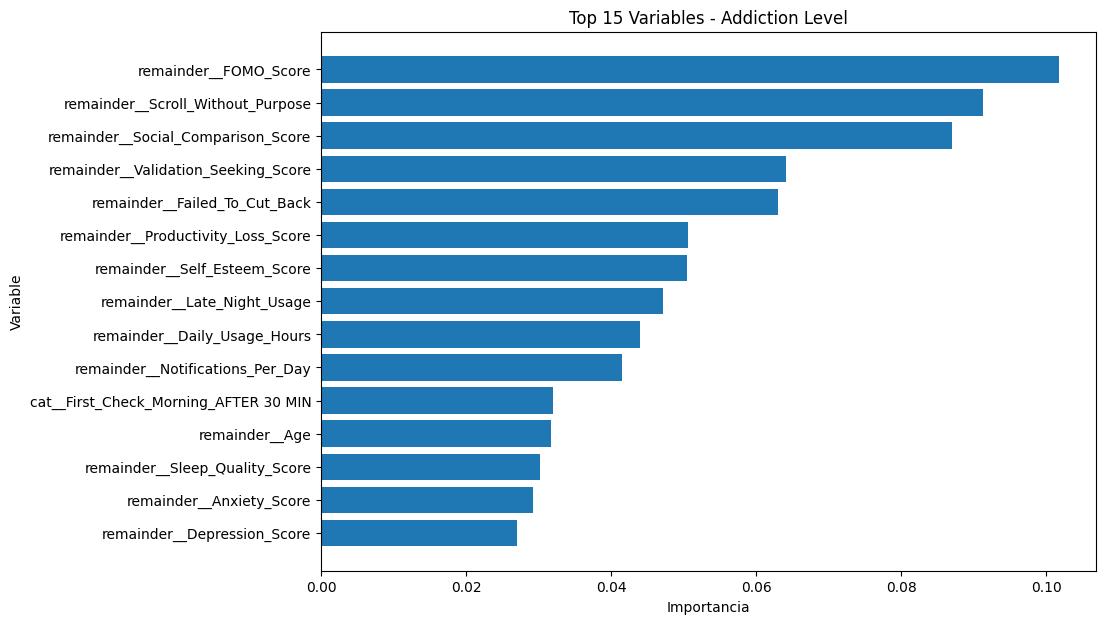

In [13]:
top15_add = feature_importance_add.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top15_add["Variable"],
    top15_add["Importancia"]
)

plt.gca().invert_yaxis()
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 15 Variables - Addiction Level")

plt.show()

El FOMO fue la variable con mayor importancia para predecir el nivel de adicción, seguida del uso de redes sin un propósito definido y la comparación social. También destacaron la dificultad para reducir el uso y la búsqueda de validación. En conjunto, el modelo sugiere que los factores conductuales y psicológicos aportaron más a la clasificación que únicamente el tiempo de uso de las redes sociales.

Sin embargo, el modelo presentó una capacidad predictiva limitada (F1 Macro = 0.38), por lo que estas importancias deben interpretarse como las variables que el árbol utilizó para tomar sus decisiones, no como evidencia de causalidad.

In [14]:
# ==========================================
# MODELO 3: MENTAL WELLBEING SCORE
# REGRESIÓN
# ==========================================

# Target numérico
y_train_mwb = train_mwb["Mental_Wellbeing_Score"]
y_test_mwb = test_mwb["Mental_Wellbeing_Score"]

# Removis:
# - User_ID: identificador
# - Mental_Wellbeing_Score: target
# - Addiction_Level: evitamos usar otra variable resumen/target
columnas_eliminar_mwb = [
    "User_ID",
    "Mental_Wellbeing_Score",
    "Addiction_Level"
]

X_train_mwb = train_mwb.drop(columns=columnas_eliminar_mwb)
X_test_mwb = test_mwb.drop(columns=columnas_eliminar_mwb)

print("X_train:", X_train_mwb.shape)
print("X_test:", X_test_mwb.shape)

print("\nTarget TRAIN:")
print(y_train_mwb.describe())

X_train: (1157, 27)
X_test: (321, 27)

Target TRAIN:
count    1157.000000
mean        6.436733
std         1.311880
min         2.500000
25%         5.500000
50%         6.400000
75%         7.400000
max        10.000000
Name: Mental_Wellbeing_Score, dtype: float64


In [15]:
categorical_features_mwb = X_train_mwb.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Variables categóricas:")
print(categorical_features_mwb)

Variables categóricas:
['Gender', 'Occupation', 'Relationship_Status', 'Primary_Platform', 'First_Check_Morning']


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor_mwb = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_mwb
        )
    ],
    remainder="passthrough"
)

In [19]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import pandas as pd

resultados_cv_mwb = []

for profundidad in [2, 3, 4, 5, 6, 7, 8, 10]:

    tree_mwb = DecisionTreeRegressor(
        max_depth=profundidad,
        random_state=46
    )

    model_cv_mwb = Pipeline(
        steps=[
            ("preprocessor", preprocessor_mwb),
            ("regressor", tree_mwb)
        ]
    )

    scores = cross_val_score(
        model_cv_mwb,
        X_train_mwb,
        y_train_mwb,
        cv=5,
        scoring="neg_mean_absolute_error"
    )

    # sklearn devuelve MAE negativo, por eso multiplicamos por -1
    mae_scores = -scores

    resultados_cv_mwb.append({
        "max_depth": profundidad,
        "mae_promedio": mae_scores.mean(),
        "desviacion": mae_scores.std()
    })

resultados_cv_mwb_df = pd.DataFrame(resultados_cv_mwb)

resultados_cv_mwb_df

,max_depth,mae_promedio,desviacion
0,2,0.967022,0.018792
1,3,0.925434,0.026535
2,4,0.929108,0.036048
3,5,0.942169,0.043182
4,6,0.966816,0.058408
5,7,1.002972,0.037672
6,8,1.017813,0.024189
7,10,1.063377,0.014870


In [20]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

final_tree_mwb = DecisionTreeRegressor(
    max_depth=3,
    random_state=46
)

final_model_mwb = Pipeline(
    steps=[
        ("preprocessor", preprocessor_mwb),
        ("regressor", final_tree_mwb)
    ]
)

# Entrenamos con todo TRAIN
final_model_mwb.fit(X_train_mwb, y_train_mwb)

# Predicción sobre TEST
y_pred_mwb = final_model_mwb.predict(X_test_mwb)

In [21]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae_mwb = mean_absolute_error(
    y_test_mwb,
    y_pred_mwb
)

rmse_mwb = np.sqrt(
    mean_squared_error(
        y_test_mwb,
        y_pred_mwb
    )
)

r2_mwb = r2_score(
    y_test_mwb,
    y_pred_mwb
)

print(f"MAE: {mae_mwb:.4f}")
print(f"RMSE: {rmse_mwb:.4f}")
print(f"R²: {r2_mwb:.4f}")

MAE: 0.9149
RMSE: 1.1237
R²: 0.1218


In [23]:
feature_names_mwb = final_model_mwb.named_steps[
    "preprocessor"
].get_feature_names_out()

importances_mwb = final_model_mwb.named_steps[
    "regressor"
].feature_importances_

feature_importance_mwb = pd.DataFrame({
    "Variable": feature_names_mwb,
    "Importancia": importances_mwb
}).sort_values(
    by="Importancia",
    ascending=False
)

feature_importance_mwb.head(15)

,Variable,Importancia
27,remainder__Late_Night_Usage,0.322186
34,remainder__Failed_To_Cut_Back,0.317196
21,cat__First_Check_Morning_AFTER 30 MIN,0.223890
22,cat__First_Check_Morning_WITHIN 5 MIN,0.080636
31,remainder__Validation_Seeking_Score,0.056091
5,cat__Occupation_STUDENT,0.000000
6,cat__Occupation_UNEMPLOYED,0.000000
7,cat__Occupation_UNKNOWN,0.000000
0,cat__Gender_FEMALE,0.000000
1,cat__Gender_MALE,0.000000


In [24]:
feature_names_mwb = final_model_mwb.named_steps[
    "preprocessor"
].get_feature_names_out()

importances_mwb = final_model_mwb.named_steps[
    "regressor"
].feature_importances_

feature_importance_mwb = pd.DataFrame({
    "Variable": feature_names_mwb,
    "Importancia": importances_mwb
}).sort_values(
    by="Importancia",
    ascending=False
)

feature_importance_mwb.head(15)

,Variable,Importancia
27,remainder__Late_Night_Usage,0.322186
34,remainder__Failed_To_Cut_Back,0.317196
21,cat__First_Check_Morning_AFTER 30 MIN,0.223890
22,cat__First_Check_Morning_WITHIN 5 MIN,0.080636
31,remainder__Validation_Seeking_Score,0.056091
5,cat__Occupation_STUDENT,0.000000
6,cat__Occupation_UNEMPLOYED,0.000000
7,cat__Occupation_UNKNOWN,0.000000
0,cat__Gender_FEMALE,0.000000
1,cat__Gender_MALE,0.000000


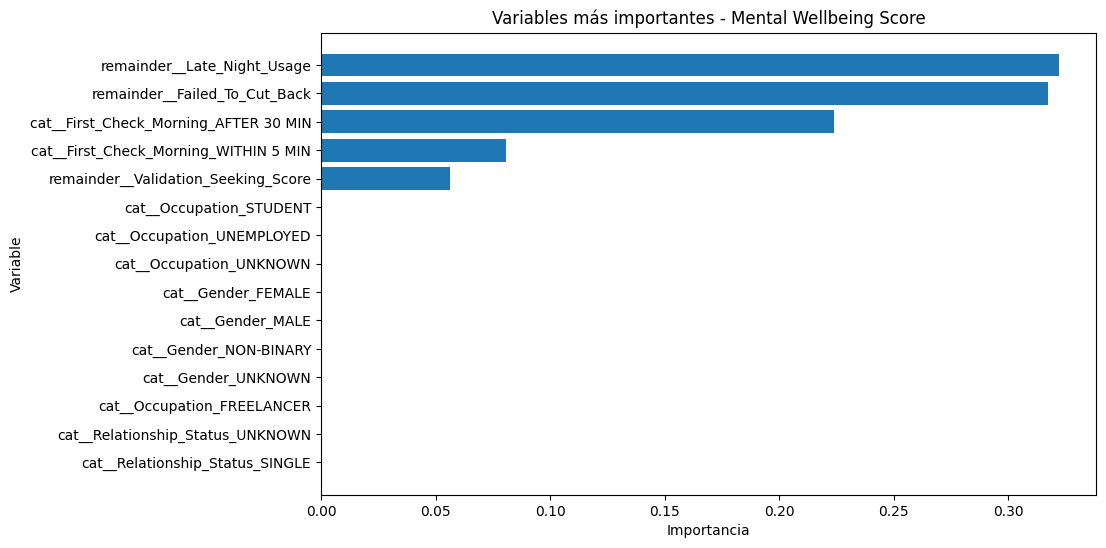

In [25]:
top15_mwb = feature_importance_mwb.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top15_mwb["Variable"],
    top15_mwb["Importancia"]
)

plt.gca().invert_yaxis()
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Variables más importantes - Mental Wellbeing Score")

plt.show()

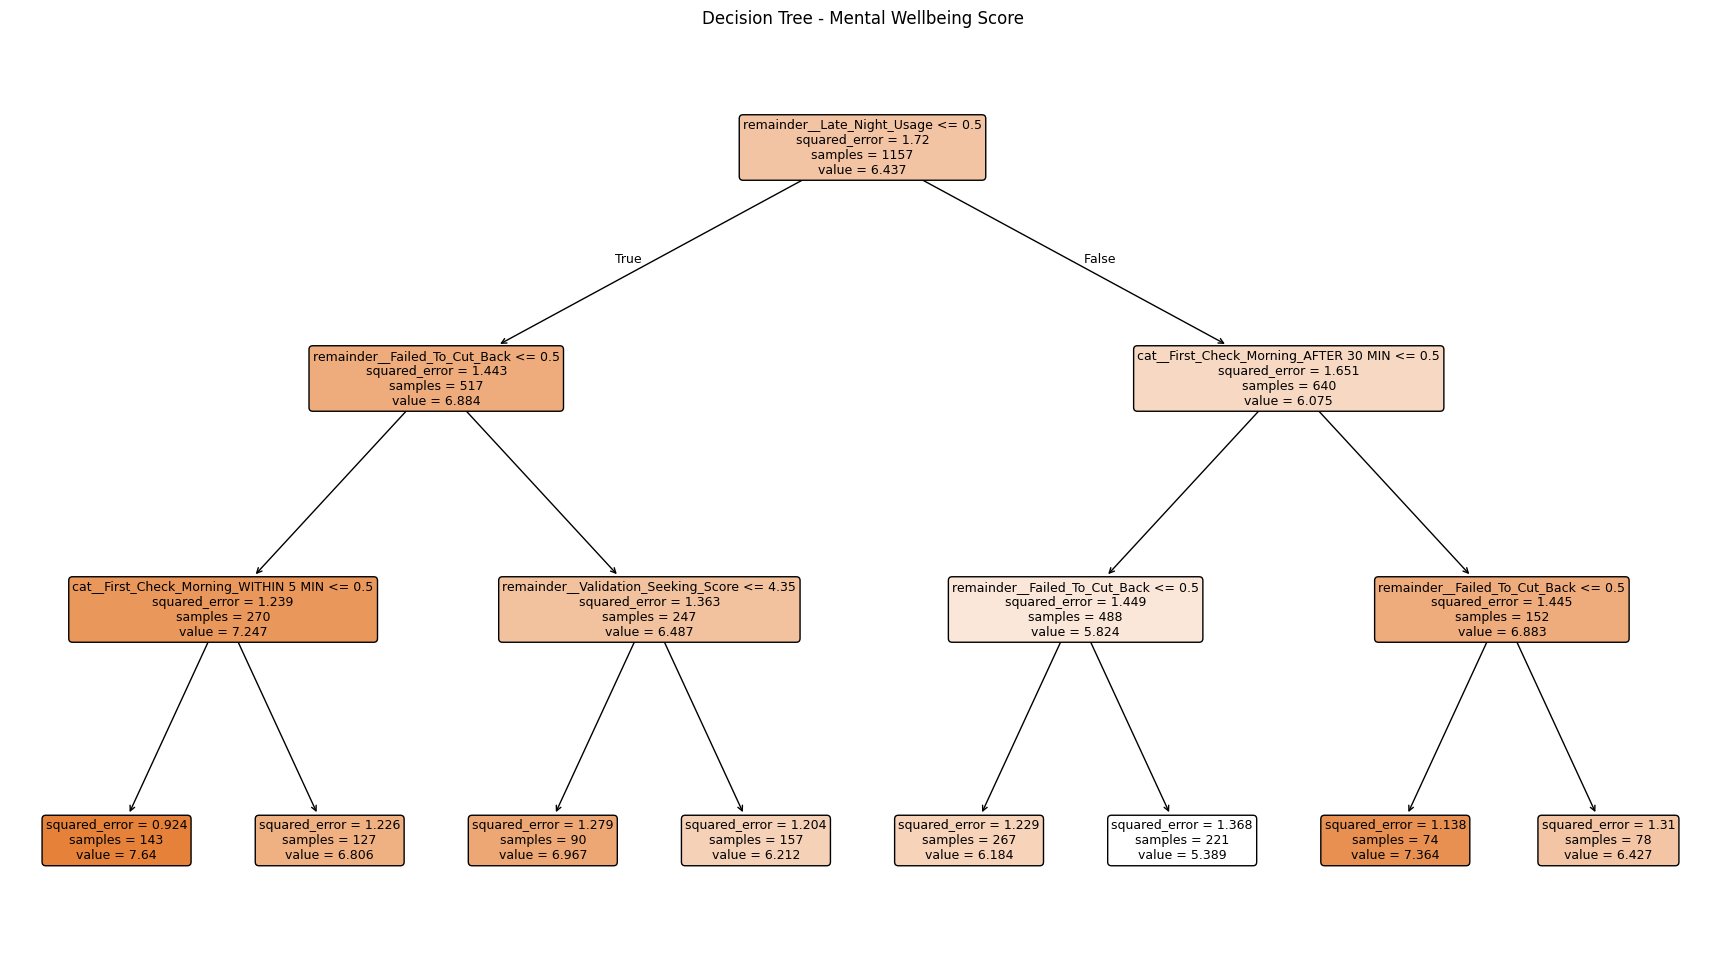

In [26]:
from sklearn.tree import plot_tree

tree_mwb_final = final_model_mwb.named_steps["regressor"]

plt.figure(figsize=(22, 12))

plot_tree(
    tree_mwb_final,
    feature_names=feature_names_mwb,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree - Mental Wellbeing Score")
plt.show()

El uso nocturno de redes sociales y la dificultad para reducir su uso fueron las variables con mayor importancia en la predicción del Mental Wellbeing Score. El árbol identificó un bienestar promedio mayor entre los usuarios sin uso nocturno (6.88) frente a quienes presentaban uso nocturno (6.08). También resultaron relevantes el momento de la primera consulta de redes por la mañana y la búsqueda de validación. Sin embargo, el modelo explicó únicamente el 12.2% de la variabilidad del bienestar (R² = 0.12), por lo que los resultados muestran asociaciones predictivas limitadas y no relaciones causales.

# ANXIETY SCORE


Predecir Anxiety_Score con regresión usando las variables de comportamiento digital

In [28]:
# ==========================================
# MODELO DE REGRESIÓN - ANXIETY SCORE
# ==========================================

features_anxiety = [
    "Daily_Usage_Hours",
    "Late_Night_Usage",
    "Notifications_Per_Day",
    "FOMO_Score",
    "Social_Comparison_Score",
    "Validation_Seeking_Score",
    "Scroll_Without_Purpose",
    "Tried_To_Cut_Back",
    "Failed_To_Cut_Back",
    "Sleep_Quality_Score",
    "Sleep_Hours",
    "Physical_Activity_Hrs_Week",
    "Screen_Free_Time_Hrs"
]

target_anxiety = "Anxiety_Score"

X_train_anxiety = train_mwb[features_anxiety]
y_train_anxiety = train_mwb[target_anxiety]

X_test_anxiety = test_mwb[features_anxiety]
y_test_anxiety = test_mwb[target_anxiety]

print("X_train:", X_train_anxiety.shape)
print("X_test:", X_test_anxiety.shape)

print("\nTarget:")
print(y_train_anxiety.describe())

X_train: (1157, 13)
X_test: (321, 13)

Target:
count    1157.000000
mean        5.151858
std         2.140014
min         0.000000
25%         3.800000
50%         5.200000
75%         6.600000
max        10.000000
Name: Anxiety_Score, dtype: float64


In [29]:
categorical_features_anxiety = (
    X_train_anxiety
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

print("Variables categóricas:")
print(categorical_features_anxiety)

Variables categóricas:
[]


In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor_anxiety = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_anxiety
        )
    ],
    remainder="passthrough"
)

In [31]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

depths = [2, 3, 4, 5, 6, 7, 8, 10]

results_anxiety = []

for depth in depths:

    model = Pipeline([
        ("preprocessor", preprocessor_anxiety),

        ("regressor", DecisionTreeRegressor(
            max_depth=depth,
            random_state=46
        ))
    ])

    scores = cross_val_score(
        model,
        X_train_anxiety,
        y_train_anxiety,
        cv=5,
        scoring="neg_mean_absolute_error"
    )

    mae_mean = -scores.mean()
    mae_std = scores.std()

    results_anxiety.append(
        [depth, mae_mean, mae_std]
    )

    print(
        f"Depth {depth} | "
        f"MAE: {mae_mean:.4f} | "
        f"STD: {mae_std:.4f}"
    )

Depth 2 | MAE: 1.7132 | STD: 0.0218
Depth 3 | MAE: 1.7262 | STD: 0.0121
Depth 4 | MAE: 1.7511 | STD: 0.0146
Depth 5 | MAE: 1.7829 | STD: 0.0287
Depth 6 | MAE: 1.8496 | STD: 0.0312
Depth 7 | MAE: 1.8766 | STD: 0.0550
Depth 8 | MAE: 1.9686 | STD: 0.0522
Depth 10 | MAE: 2.1226 | STD: 0.0821


In [32]:
import pandas as pd

results_anxiety_df = pd.DataFrame(
    results_anxiety,
    columns=[
        "max_depth",
        "MAE_CV",
        "STD"
    ]
)

results_anxiety_df = (
    results_anxiety_df
    .sort_values("MAE_CV")
)

results_anxiety_df

,max_depth,MAE_CV,STD
0,2,1.713240,0.021795
1,3,1.726187,0.012088
2,4,1.751142,0.014617
3,5,1.782859,0.028706
4,6,1.849586,0.031248
5,7,1.876643,0.055011
6,8,1.968641,0.052165
7,10,2.122631,0.082119


In [33]:
best_depth_anxiety = int(
    results_anxiety_df.iloc[0]["max_depth"]
)

print(
    "Mejor max_depth:",
    best_depth_anxiety
)

Mejor max_depth: 2


In [34]:
final_anxiety_tree = Pipeline([
    ("preprocessor", preprocessor_anxiety),

    ("regressor", DecisionTreeRegressor(
        max_depth=best_depth_anxiety,
        random_state=46
    ))
])

final_anxiety_tree.fit(
    X_train_anxiety,
    y_train_anxiety
)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as a different type depending on the ColumnTransformer inputs.
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [])])),
                ('regressor',
                 DecisionTreeRegressor(max_depth=2, random_state=46))])

In [35]:
y_pred_anxiety = final_anxiety_tree.predict(
    X_test_anxiety
)

In [36]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae_anxiety = mean_absolute_error(
    y_test_anxiety,
    y_pred_anxiety
)

rmse_anxiety = np.sqrt(
    mean_squared_error(
        y_test_anxiety,
        y_pred_anxiety
    )
)

r2_anxiety = r2_score(
    y_test_anxiety,
    y_pred_anxiety
)

print(f"MAE: {mae_anxiety:.4f}")
print(f"RMSE: {rmse_anxiety:.4f}")
print(f"R²: {r2_anxiety:.4f}")
print(f"R² (%): {r2_anxiety * 100:.2f}%")

MAE: 1.6827
RMSE: 2.1313
R²: -0.0513
R² (%): -5.13%


*  MAE = 1.6827 → en promedio se equivoca ~1.68 puntos de ansiedad.
*  RMSE = 2.1313 → hay errores grandes que están penalizando más.
*  R² = -0.0513 → esto es lo más importante: el modelo explica menos que un modelo básico que siempre predijera la media.


Un R² negativo significa que, con estas variables y este árbol, la capacidad predictiva es prácticamente nula

# ¿Puede un árbol de decisión identificar usuarios con mayor riesgo de adicción?


## Decision Tree - Predicción de riesgo de adicción

En el análisis anterior se intentó predecir `Addiction_Level` utilizando cuatro
categorías: LOW, MODERATE, HIGH y SEVERE.

Debido a que diferenciar cuatro niveles puede ser más complejo para el modelo,
en este análisis se reformula el problema como una clasificación binaria.

Se agrupan los niveles de adicción en:

- LOWER_RISK: LOW + MODERATE
- HIGHER_RISK: HIGH + SEVERE

El objetivo es evaluar si un árbol de decisión puede identificar usuarios con
mayor riesgo de adicción a partir de sus características de comportamiento,
uso de redes sociales y factores psicológicos.

In [39]:
# ============================================================
# 1. CREACIÓN DEL TARGET BINARIO: ADDICTION RISK
# ============================================================



train_mwb["Addiction_Risk"] = train_mwb["Addiction_Level"].map({
    "LOW": "LOWER_RISK",
    "MODERATE": "LOWER_RISK",
    "HIGH": "HIGHER_RISK",
    "SEVERE": "HIGHER_RISK"
})

test_mwb["Addiction_Risk"] = test_mwb["Addiction_Level"].map({
    "LOW": "LOWER_RISK",
    "MODERATE": "LOWER_RISK",
    "HIGH": "HIGHER_RISK",
    "SEVERE": "HIGHER_RISK"
})

# Revisamos cuántos usuarios hay en cada nueva categoría.
print("TRAIN:")
print(train_mwb["Addiction_Risk"].value_counts())

print("\nTEST:")
print(test_mwb["Addiction_Risk"].value_counts())

TRAIN:
Addiction_Risk
LOWER_RISK     659
HIGHER_RISK    498
Name: count, dtype: int64

TEST:
Addiction_Risk
LOWER_RISK     201
HIGHER_RISK    120
Name: count, dtype: int64


Para el siguiente Elimine variables que no deben utilizarse para predecir.

- User_ID: Es únicamente un identificador del usuario y no aporta información predictiva útil.
-  Addiction_Level: Addiction_Risk fue creado directamente a partir de esta variable.
- Addiction_Risk: Es nuestro target, por lo tanto tampoco puede formar parte de X.

- Mental_Wellbeing_Score: Lo excluí  para centrar el análisis en características comportamentales y psicológicas específicas y no utilizar una puntuación global de bienestar como predictor.

In [40]:
# ============================================================
# 2. DEFINICIÓN DE VARIABLES PREDICTORAS (X) Y TARGET (y)
# ============================================================

# Nuestro objetivo (y) será predecir Addiction_Risk.
y_train_risk = train_mwb["Addiction_Risk"]
y_test_risk = test_mwb["Addiction_Risk"]




columns_to_exclude_risk = [
    "User_ID",
    "Addiction_Level",
    "Addiction_Risk",
    "Mental_Wellbeing_Score"
]

X_train_risk = train_mwb.drop(
    columns=columns_to_exclude_risk
)

X_test_risk = test_mwb.drop(
    columns=columns_to_exclude_risk
)

print("X_train:", X_train_risk.shape)
print("X_test:", X_test_risk.shape)

print("\nDistribución del target TRAIN:")
print(y_train_risk.value_counts())

print("\nDistribución porcentual:")
print(
    y_train_risk.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

X_train: (1157, 27)
X_test: (321, 27)

Distribución del target TRAIN:
Addiction_Risk
LOWER_RISK     659
HIGHER_RISK    498
Name: count, dtype: int64

Distribución porcentual:
Addiction_Risk
LOWER_RISK     56.96
HIGHER_RISK    43.04
Name: proportion, dtype: float64


In [43]:

# IDENTIFICACIÓN DE VARIABLES CATEGÓRICAS


categorical_features_risk = (
    X_train_risk
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

print("Variables categóricas:")
print(categorical_features_risk)

print("\nNúmero de variables categóricas:")
print(len(categorical_features_risk))

Variables categóricas:
['Gender', 'Occupation', 'Relationship_Status', 'Primary_Platform', 'First_Check_Morning']

Número de variables categóricas:
5


In [44]:

# PREPROCESAMIENTO


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


preprocessor_risk = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_risk
        )
    ],
    remainder="passthrough"
)

In [45]:
# SELECCIÓN DE MAX_DEPTH MEDIANTE CROSS-VALIDATION

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score


# Un árbol demasiado pequeño puede ser demasiado simple.
# Un árbol demasiado profundo puede memorizar TRAIN y producir overfitting.

depths = [2, 3, 4, 5, 6, 7, 8, 10]

results_risk = []

for depth in depths:



    model_risk = Pipeline([
        ("preprocessor", preprocessor_risk),

        ("classifier", DecisionTreeClassifier(
            max_depth=depth,

            #
            random_state=46,


            class_weight="balanced"
        ))
    ])


    scores = cross_val_score(
        model_risk,
        X_train_risk,
        y_train_risk,
        cv=5,
        scoring="f1_macro"
    )

    results_risk.append([
        depth,
        scores.mean(),
        scores.std()
    ])

    print(
        f"Depth {depth} | "
        f"F1 Macro: {scores.mean():.4f} | "
        f"STD: {scores.std():.4f}"
    )

Depth 2 | F1 Macro: 0.6313 | STD: 0.0160
Depth 3 | F1 Macro: 0.6481 | STD: 0.0143
Depth 4 | F1 Macro: 0.6547 | STD: 0.0412
Depth 5 | F1 Macro: 0.6549 | STD: 0.0107
Depth 6 | F1 Macro: 0.6671 | STD: 0.0466
Depth 7 | F1 Macro: 0.6688 | STD: 0.0214
Depth 8 | F1 Macro: 0.6685 | STD: 0.0275
Depth 10 | F1 Macro: 0.6663 | STD: 0.0379


In [46]:
 # SELECCIÓN AUTOMÁTICA DEL MEJOR MAX_DEPTH SEGUN EL RESULTADO ANTERIOR


import pandas as pd

# Convertimos los resultados obtenidos en cross-validation
# en una tabla para poder compararlos fácilmente.

results_risk_df = pd.DataFrame(
    results_risk,
    columns=[
        "max_depth",
        "F1_Macro_CV",
        "STD"
    ]
)

# Ordenamos por F1 Macro de mayor a menor.
# Como en clasificación un F1 más alto es mejor,
# la primera fila será la mejor profundidad.

results_risk_df = results_risk_df.sort_values(
    "F1_Macro_CV",
    ascending=False
)

display(results_risk_df)

# Guardamos automáticamente la profundidad ganadora.
best_depth_risk = int(
    results_risk_df.iloc[0]["max_depth"]
)

print("Mejor max_depth:", best_depth_risk)

,max_depth,F1_Macro_CV,STD
5,7,0.668793,0.021376
6,8,0.668463,0.027549
4,6,0.667122,0.046562
7,10,0.666269,0.037908
3,5,0.654948,0.010735
2,4,0.654669,0.041189
1,3,0.648057,0.014306
0,2,0.631280,0.016022


Mejor max_depth: 7


In [47]:
#  ENTRENAMIENTO DEL ÁRBOL FINAL

final_risk_model = Pipeline([
    ("preprocessor", preprocessor_risk),

    ("classifier", DecisionTreeClassifier(
        max_depth=best_depth_risk,
        random_state=46,
        class_weight="balanced"
    ))
])

final_risk_model.fit(
    X_train_risk,
    y_train_risk
)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Occupation',
                                                   'Relationship_Status',
                                                   'Primary_Platform',
                                                   'First_Check_Morning'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=7,
                                        random_state=46))])

In [49]:
y_pred_risk = final_risk_model.predict(
    X_test_risk
)

In [51]:
# ENTRENAR MODELO FINAL
final_risk_model = Pipeline([
    ("preprocessor", preprocessor_risk),

    ("classifier", DecisionTreeClassifier(
        max_depth=best_depth_risk,
        random_state=46,
        class_weight="balanced"
    ))
])

final_risk_model.fit(
    X_train_risk,
    y_train_risk
)

print("Modelo final entrenado correctamente")

Modelo final entrenado correctamente


In [52]:

y_pred_risk = final_risk_model.predict(
    X_test_risk
)

print("Predicciones realizadas:", len(y_pred_risk))

Predicciones realizadas: 321


In [53]:
# EVALUACIÓN DEL MODELO

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

# Accuracy = porcentaje total de usuarios clasificados correctamente.
accuracy_risk = accuracy_score(
    y_test_risk,
    y_pred_risk
)

# F1 Macro = calcula el rendimiento de cada clase
# y les da la misma importancia.
f1_risk = f1_score(
    y_test_risk,
    y_pred_risk,
    average="macro"
)

print(f"Accuracy: {accuracy_risk:.4f}")
print(f"Accuracy (%): {accuracy_risk * 100:.2f}%")
print(f"F1 Macro: {f1_risk:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test_risk,
        y_pred_risk,
        zero_division=0
    )
)

Accuracy: 0.6667
Accuracy (%): 66.67%
F1 Macro: 0.6597

Classification Report:
              precision    recall  f1-score   support

 HIGHER_RISK       0.54      0.70      0.61       120
  LOWER_RISK       0.78      0.65      0.71       201

    accuracy                           0.67       321
   macro avg       0.66      0.67      0.66       321
weighted avg       0.69      0.67      0.67       321



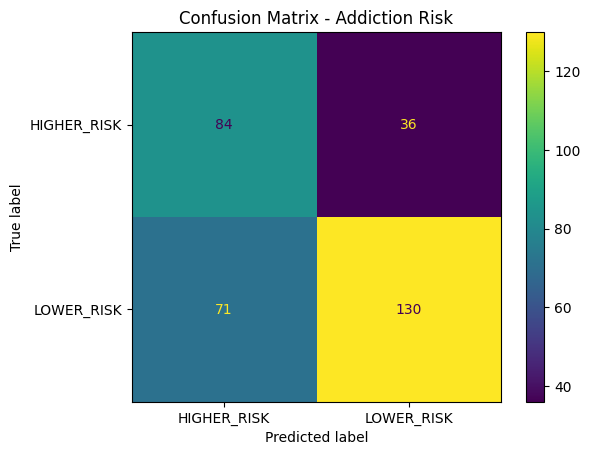

Orden de las clases: ['HIGHER_RISK' 'LOWER_RISK']

Matriz:
[[ 84  36]
 [ 71 130]]


In [54]:

# MATRIZ DE CONFUSIÓN


from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

class_names_risk = (
    final_risk_model
    .named_steps["classifier"]
    .classes_
)

cm_risk = confusion_matrix(
    y_test_risk,
    y_pred_risk,
    labels=class_names_risk
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_risk,
    display_labels=class_names_risk
)

disp.plot()

plt.title(
    "Confusion Matrix - Addiction Risk"
)

plt.show()

print("Orden de las clases:", class_names_risk)
print("\nMatriz:")
print(cm_risk)

Al reformular Addiction Level como un problema binario de mayor y menor riesgo, el árbol alcanzó un Accuracy de 66.67% y un F1 Macro de 0.66. El modelo identificó correctamente el 70% de los usuarios del grupo Higher Risk, aunque también generó falsos positivos al clasificar 71 usuarios Lower Risk como Higher Risk

In [55]:
#  IMPORTANCIA DE VARIABLES


feature_names_risk = (
    final_risk_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Extraemos el árbol entrenado del Pipeline.

tree_risk = (
    final_risk_model
    .named_steps["classifier"]
)



importance_risk = pd.DataFrame({
    "Feature": feature_names_risk,
    "Importance": tree_risk.feature_importances_
})

# Ordenamos de mayor a menor importancia.

importance_risk = (
    importance_risk
    .sort_values(
        "Importance",
        ascending=False
    )
)

# Mostramos las 15 variables más importantes.

importance_risk.head(15)

,Feature,Importance
29,remainder__FOMO_Score,0.099412
34,remainder__Failed_To_Cut_Back,0.099357
24,remainder__Daily_Usage_Hours,0.085344
35,remainder__Anxiety_Score,0.077771
22,cat__First_Check_Morning_WITHIN 5 MIN,0.076771
42,remainder__Offline_Relationship_Quality,0.058441
32,remainder__Scroll_Without_Purpose,0.056912
30,remainder__Social_Comparison_Score,0.047934
31,remainder__Validation_Seeking_Score,0.040495
28,remainder__Notifications_Per_Day,0.039506


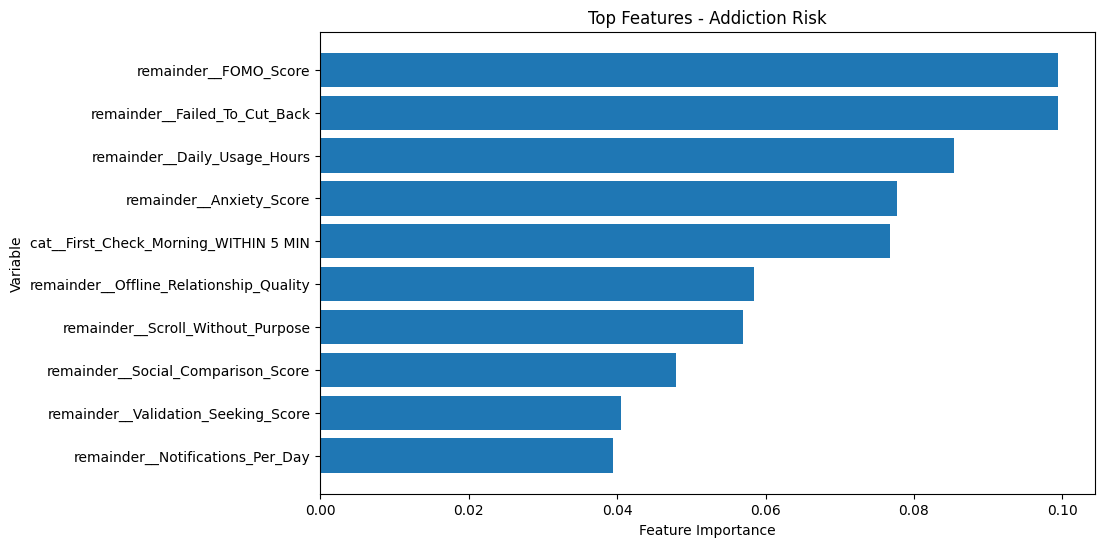

In [56]:
# TOP 10 VARIABLES MÁS IMPORTANTES


top_risk = importance_risk.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_risk["Feature"],
    top_risk["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Variable")

plt.title(
    "Top Features - Addiction Risk"
)

plt.show()


El modelo binario de riesgo de adicción obtuvo un Accuracy de **66.67%** y un
F1 Macro de **0.66**.

El modelo identificó correctamente el **70% de los usuarios clasificados como
HIGHER_RISK** (recall = 0.70). De los 120 usuarios de mayor riesgo presentes
en el conjunto de test, 84 fueron identificados correctamente y 36 fueron
clasificados como LOWER_RISK.

Las variables con mayor importancia para el árbol fueron **FOMO Score**,
**Failed To Cut Back**, **Daily Usage Hours**, **Anxiety Score** y la consulta
de redes sociales dentro de los primeros cinco minutos después de despertar.

También aparecieron entre las variables relevantes la calidad de las relaciones
offline, el scrolling sin propósito, la comparación social, la búsqueda de
validación y el número de notificaciones diarias.

Estos resultados sugieren que la clasificación del riesgo no depende únicamente
del tiempo de uso de redes sociales, sino también de patrones conductuales y
factores psicológicos asociados al uso digital.

Las importancias del modelo representan asociaciones predictivas utilizadas por
el árbol de decisión y no deben interpretarse como relaciones causales.

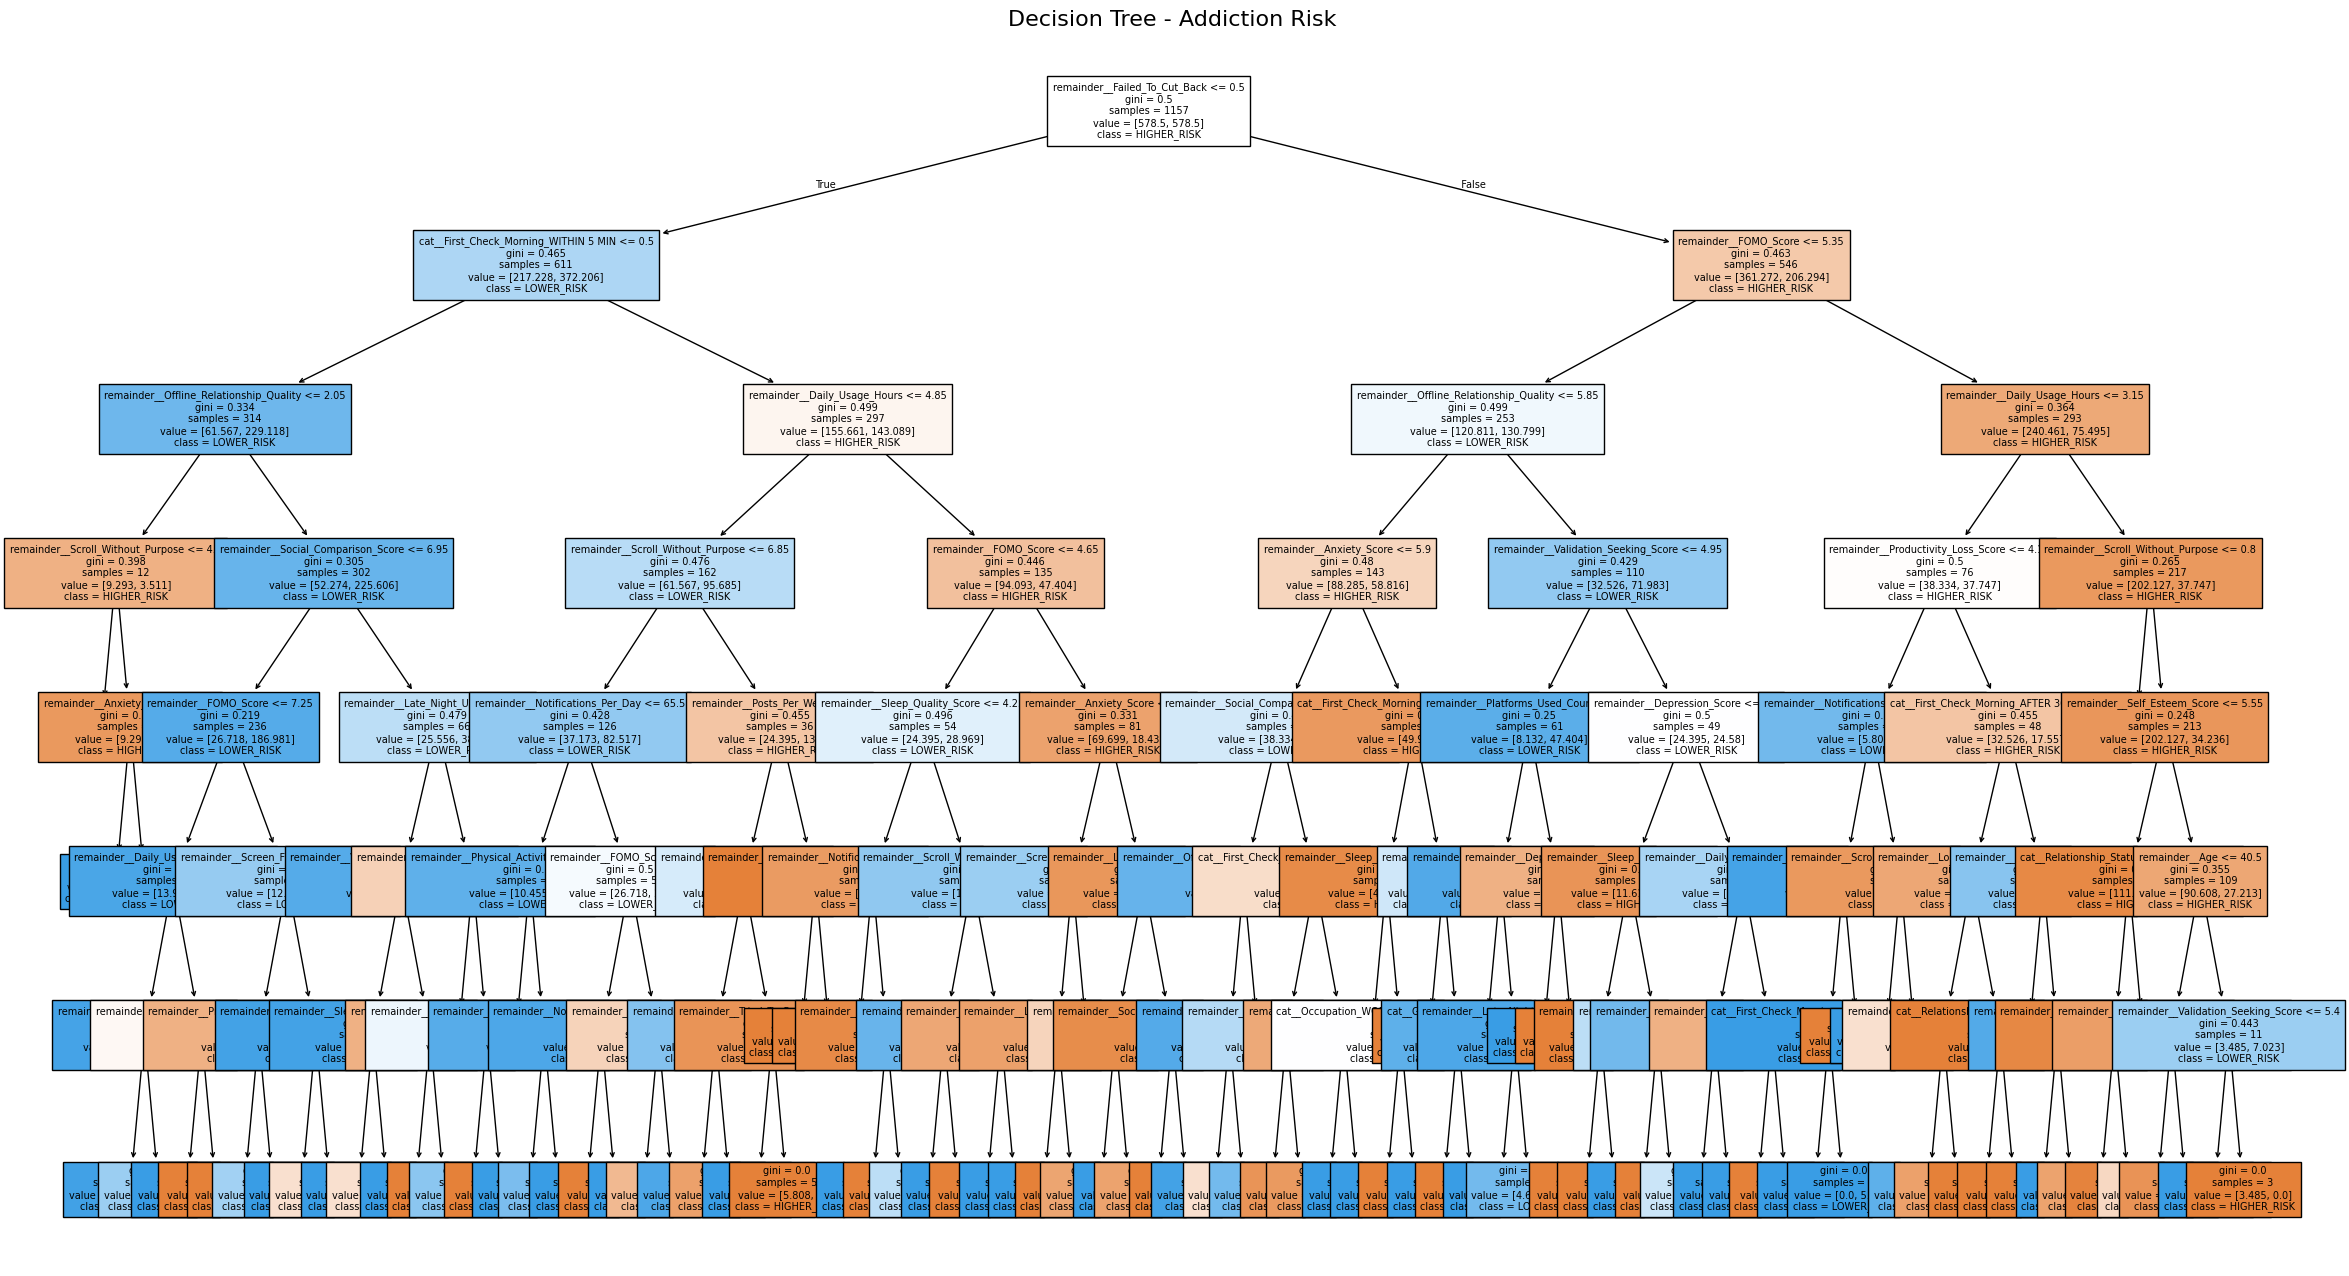

In [57]:
# VISUALIZACIÓN DEL ÁRBOL DE DECISIÓN


feature_names_risk = (
    final_risk_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)



tree_risk = (
    final_risk_model
    .named_steps["classifier"]
)

# Creamos una figura grande porque nuestro mejor árbol
# tiene max_depth = 7 y puede contener bastantes nodos.

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(28, 16))

plot_tree(
    tree_risk,


    feature_names=feature_names_risk,

    class_names=tree_risk.classes_,


    filled=True,



    fontsize=7
)

plt.title(
    "Decision Tree - Addiction Risk",
    fontsize=16
)

plt.show()

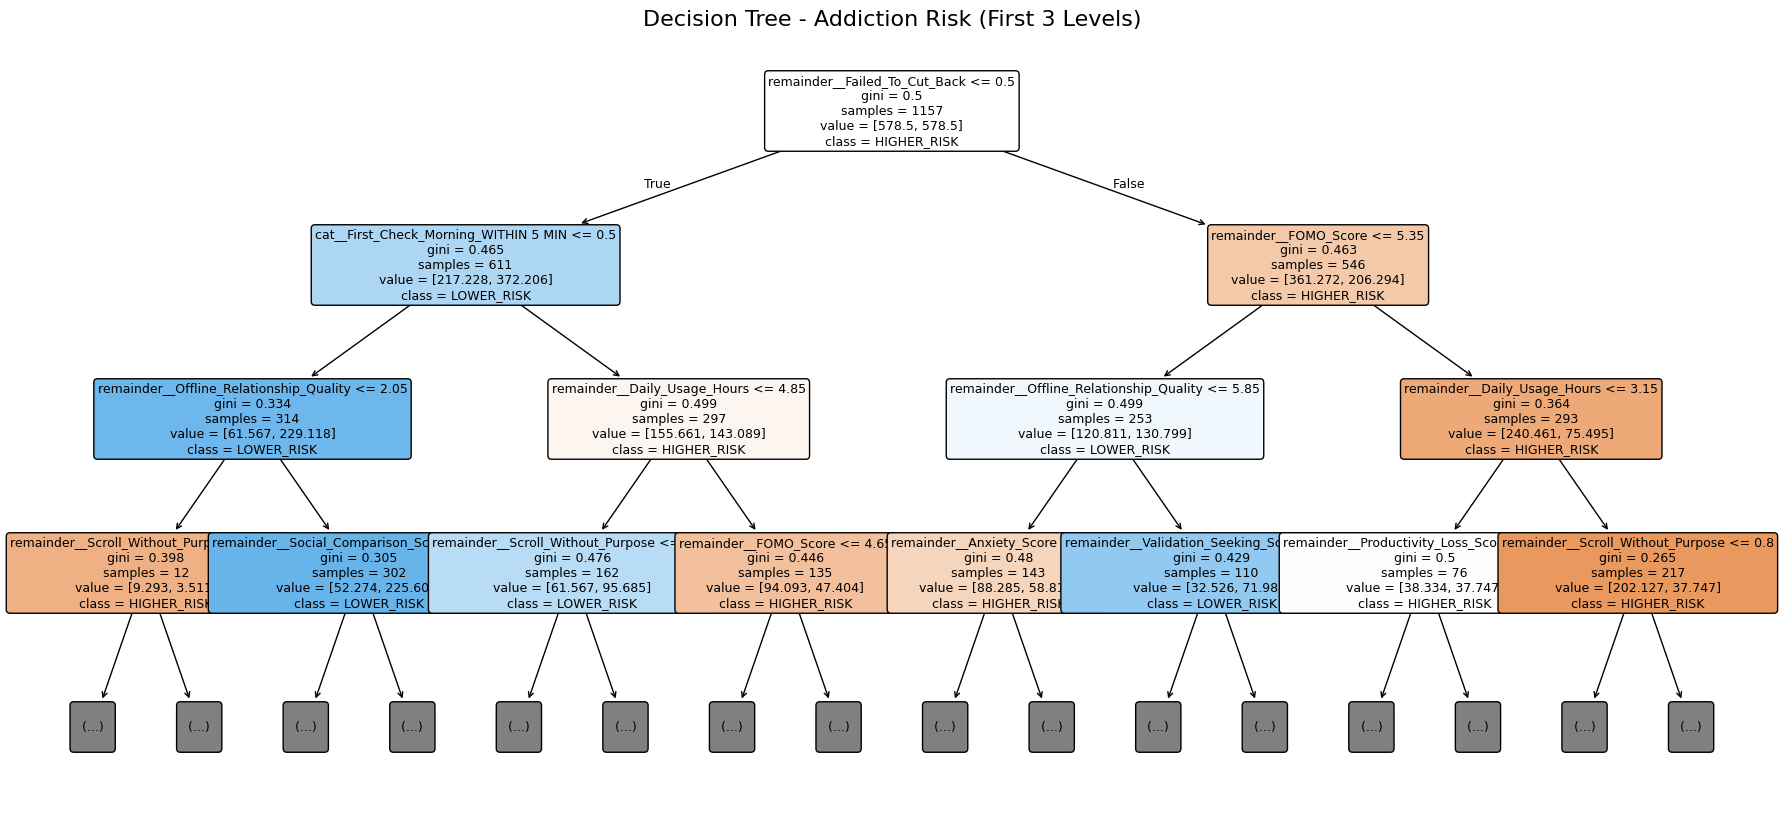

In [58]:
#  VISTA RESUMIDA DEL ÁRBOL PARA INTERPRETACIÓN

plt.figure(figsize=(22, 10))

plot_tree(
    tree_risk,
    feature_names=feature_names_risk,
    class_names=tree_risk.classes_,
    filled=True,
    rounded=True,
    fontsize=9,

    # Solo limita lo que SE MUESTRA, no el modelo entrenado.
    max_depth=3
)

plt.title(
    "Decision Tree - Addiction Risk (First 3 Levels)",
    fontsize=16
)

plt.show()


La primera división del árbol se realiza mediante `Failed_To_Cut_Back`,
lo que indica que la dificultad para reducir voluntariamente el uso de
redes sociales constituye una de las principales variables utilizadas
por el modelo para diferenciar los grupos de riesgo.

Entre los usuarios que han fallado al intentar reducir su uso, el
`FOMO_Score` aparece como la siguiente variable principal de
segmentación. En particular, valores de FOMO superiores a 5.35 se
asocian en el árbol con una mayor presencia de usuarios clasificados
como `HIGHER_RISK`.

El modelo también utiliza variables como el momento de la primera
consulta de redes después de despertar, las horas de uso diario,
el scrolling sin propósito, la comparación social, la pérdida de
productividad y la calidad de las relaciones offline.

Por tanto, el árbol sugiere que la identificación del riesgo de
adicción depende de una combinación de hábitos de uso, dificultad
de autorregulación y factores sociales y psicológicos, y no
exclusivamente del tiempo diario de uso.

Estos patrones representan asociaciones predictivas dentro del
modelo y no implican relaciones causales.

**La primera variable que utiliza el árbol es la dificultad para reducir el uso. A partir de ahí, combina FOMO, revisión de redes al despertar, horas de uso y otros comportamientos. El modelo binario alcanzó 66.7% de accuracy y detectó el 70% de los usuarios Higher Risk**